# GRHD Shock Tube PINN with Sobol Sampling
This notebook builds a small physics-informed neural network for the relativistic Sod shock tube.
We follow the reference structure from the GA_PINNs repository, while keeping Sobol sampling in this implementation.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import pytorch_optimizer

In [ ]:
def set_plot_style():
    plt.rcParams.update({
        'figure.figsize': (10, 5),
        'axes.grid': True,
        'font.size': 12,
    })

set_plot_style()

#### network architecture

In [ ]:
class GRHDPINN(nn.Module):
    def __init__(self, hidden_size=32, n_hidden=5):
        super().__init__()
        layers = [nn.Linear(2, hidden_size), nn.Tanh()]
        for _ in range(n_hidden - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.Tanh()])
        self.network = nn.Sequential(*layers)
        self.head_rho = nn.Linear(hidden_size, 1)
        self.head_v = nn.Linear(hidden_size, 1)
        self.head_p = nn.Linear(hidden_size, 1)

    def forward(self, x, t):
        features = self.network(torch.cat([x, t], dim=1))
        rho = nn.functional.softplus(self.head_rho(features)) + 1e-6
        p = nn.functional.softplus(self.head_p(features)) + 1e-6
        v = torch.tanh(self.head_v(features))
        return rho, v, p

In [5]:
gamma = 5.0 / 3.0

epsilon_t = 1.0

tmin, tmax = 0.0, 0.5
xmin, xmax = 0.0, 1.0

N_t = 2**8
N_x = 2**7
N_0 = 2**6

X_list = []

sampler = qmc.Sobol(d=1, scramble=False)
sampler = sampler.random_base2(m=int(np.log2(N_t)))
l_bounds, u_bounds = [tmin], [tmax]
sample_scaled = qmc.scale(sampler, l_bounds, u_bounds)
t = torch.tensor(sample_scaled, dtype=torch.float32)

for value in t:
    sampler = qmc.Sobol(d=1, scramble=False)
    sampler = sampler.random_base2(m=int(np.log2(N_x)))
    l_bounds, u_bounds = [xmin], [xmax]
    sample_scaled = qmc.scale(sampler, l_bounds, u_bounds)
    x = torch.tensor(sample_scaled, dtype=torch.float32)
    t_repeated = torch.tensor(float(value.detach().cpu().numpy())).repeat(x.shape[0], 1 )
    X_list.append(torch.cat([t_repeated, x], dim=1))
X = torch.cat(X_list, dim=0)
X.requires_grad_(True)

## Generate initial data
t_0 = torch.tensor(tmin).repeat((N_0, 1)).view(-1, 1)
sampler = qmc.Sobol(d=1, scramble=False)
sampler = sampler.random_base2(m=int(np.log2(N_0)))
l_bounds, u_bounds = [xmin], [xmax]
sample_scaled = qmc.scale(sampler, l_bounds, u_bounds)
x_0 = torch.tensor(sample_scaled, dtype=torch.float32)
X_0 = torch.cat((t_0, x_0), dim=1)
X_0.requires_grad_(True)

/tmp/ipykernel_231739/4176361595.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_repeated = torch.tensor(float(value.detach().cpu().numpy())).repeat(x.shape[0], 1 )


tensor([[0.0000, 0.0000],
        [0.0000, 0.5000],
        [0.0000, 0.7500],
        [0.0000, 0.2500],
        [0.0000, 0.3750],
        [0.0000, 0.8750],
        [0.0000, 0.6250],
        [0.0000, 0.1250],
        [0.0000, 0.1875],
        [0.0000, 0.6875],
        [0.0000, 0.9375],
        [0.0000, 0.4375],
        [0.0000, 0.3125],
        [0.0000, 0.8125],
        [0.0000, 0.5625],
        [0.0000, 0.0625],
        [0.0000, 0.0938],
        [0.0000, 0.5938],
        [0.0000, 0.8438],
        [0.0000, 0.3438],
        [0.0000, 0.4688],
        [0.0000, 0.9688],
        [0.0000, 0.7188],
        [0.0000, 0.2188],
        [0.0000, 0.1562],
        [0.0000, 0.6562],
        [0.0000, 0.9062],
        [0.0000, 0.4062],
        [0.0000, 0.2812],
        [0.0000, 0.7812],
        [0.0000, 0.5312],
        [0.0000, 0.0312],
        [0.0000, 0.0469],
        [0.0000, 0.5469],
        [0.0000, 0.7969],
        [0.0000, 0.2969],
        [0.0000, 0.4219],
        [0.0000, 0.9219],
        [0.0

In [ ]:
## Initial conditions
rho_L, rho_R = 1.0, 0.125
p_L, p_R = 1.0, 0.1
v_L, v_R = 0.5, 0.5

x_numpy = X_0[:, 1:2].detach().cpu().numpy()

ic_rho = lambda x: rho_L * (x<=0.5) + rho_R * (x>0.5)
ic_p = lambda x: p_L * (x<=0.5) + p_R * (x>0.5)
ic_v = lambda x: v_L * (x<=0.5) + v_R * (x>0.5)

W_tensor = torch.tensor(1/(1-(ic_v(x_numpy)**2))**(1/2), requires_grad=True)

rho_tensor = torch.tensor(ic_rho(x_numpy), dtype=torch.float32, requires_grad=True )
p_tensor = torch.tensor(ic_p(x_numpy), dtype=torch.float32, requires_grad=True )
v_tensor = torch.tensor(ic_v(x_numpy), dtype=torch.float32, requires_grad=True )

output_ic = torch.cat([rho_tensor, v_tensor, p_tensor], dim=1)

In [7]:
def grad_y(outputs, inputs):
    return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True)[0]


#### Loss calculation. Loss definition is from the paper Antonio Ferrer-Sanchez et.al 2024

In [ ]:
def compute_grhd_loss(model, X, X_0, output_ic, gamma, N_t, N_x):

    t = X[:, 0:1]
    x = X[:, 1:2]

    rho, v, p = model(x, t)

    W = 1.0 / torch.sqrt(1 - v**2)

    ## compute conserved variables
    D = rho * W
    S_x = v*(rho+ p*gamma/(gamma-1)) * W**2
    tau = (rho + p*gamma/(gamma-1)) * W**2 - p

    ## compute fluxes
    F_D = D*v
    F_S_x = S_x*v + p
    F_tau = (tau + p)*v

    ## compute derivatives
    dD_dt = grad_y(D, t)
    dS_x_dt = grad_y(S_x, t)
    dtau_dt = grad_y(tau, t)

    dF_D_dx = grad_y(F_D, x)
    dF_S_x_dx = grad_y(F_S_x, x)
    dF_tau_dx = grad_y(F_tau, x)

    d_rho_dx = grad_y(rho, x)
    d_v_dx = grad_y(v, x)
    d_p_dx = grad_y(p, x)

    d_rho_dx_safe = torch.abs(d_rho_dx).clamp_min(1e-8)
    d_v_dx_safe = torch.abs(d_v_dx).clamp_min(1e-8)
    d_p_dx_safe = torch.abs(d_p_dx).clamp_min(1e-8)

    alpha_rho, alpha_v, alpha_p = 1.0,1.0,1.0
    beta_rho, beta_v, beta_p = 1.0,1.0,1.0
    Lambda = 1.0 /(1.0 + (alpha_rho * torch.abs(d_rho_dx_safe)**beta_rho 
                    + alpha_v * torch.abs(d_v_dx_safe)**beta_v 
                    + alpha_p * torch.abs(d_p_dx_safe)**beta_p)).view(N_t,N_x,1)
    
    ## losses 
    L_t_1 = (dD_dt + dF_D_dx).pow(2).view(N_t,N_x,1)
    L_t_2 = (dS_x_dt + dF_S_x_dx).pow(2).view(N_t,N_x,1)
    L_t_3 = (dtau_dt + dF_tau_dx).pow(2).view(N_t,N_x,1)

    ## total loss
    L_t = torch.mean(Lambda * (L_t_1 + L_t_2 + L_t_3), dim=1)

    ## compute loss for initial conditions
    prediction_tmin = (model(X_0[:, 1:2], X_0[:, 0:1]))

    w_rho, w_v, w_p = 1e4, 1e4, 1e4
    w_r = 1.0

    L_ic_rho = w_rho * torch.square(output_ic[:, 0:1] - prediction_tmin[0]).mean()
    L_ic_v = w_v * torch.square(output_ic[:, 1:2] - prediction_tmin[1]).mean()
    L_ic_p = w_p * torch.square(output_ic[:, 2:3] - prediction_tmin[2]).mean()
    L_ic = L_ic_rho + L_ic_v + L_ic_p

    L_t = torch.cat((L_ic.view(-1,1), w_r*L_t[1:]), dim=0)

    ## causality condition
    if epsilon_t != 0.0:
        zeros_t = torch.zeros(1, 1, device=X.device, dtype=L_t.dtype)
        L_t_shifted = torch.cat((zeros_t, L_t[:-1]), dim=0)
        L_t_cumsum = torch.cumsum(L_t_shifted, dim=0)
        w_t = torch.exp(-epsilon_t * L_t_cumsum)
        L_total = (w_t * L_t).mean()
    else:
        L_total = L_t.mean()

    return L_total

In [ ]:
# Training with best-model tracking
model = GRHDPINN(hidden_size=50, n_hidden=6)
# optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=1e-04)

best_loss = float('inf')
best_model_state = None

loss_history = []

print('Starting SOAP training...')
for epoch in range(30000):
    optimizer.zero_grad()
    loss = compute_grhd_loss(model, X, X_0, output_ic, gamma, N_t, N_x)
    loss.backward()
    optimizer.step()
    
    loss_val = loss.item()
    loss_history.append(loss_val)
    if loss_val < best_loss:
        best_loss = loss_val
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    if epoch % 1000 == 0:
        print(f'Epoch {epoch:04d} | Loss = {loss_val:.6f} | Best = {best_loss:.6f}')

print(f'\nSOAP training complete. Best loss = {best_loss:.6f}')
print('Restoring best model before L-BFGS...')
model.load_state_dict(best_model_state)

print('Running L-BFGS refinement (up to 50 iterations)...')
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=50, history_size=20, line_search_fn='strong_wolfe')

def closure():
    optimizer_lbfgs.zero_grad()
    loss = compute_grhd_loss(model, X, X_0, output_ic, gamma, N_t, N_x)
    loss.backward()
    return loss

lbfgs_loss_before = closure().item()
print(f'L-BFGS starting loss = {lbfgs_loss_before:.6f}')

optimizer_lbfgs.step(closure)

lbfgs_loss_after = closure().item()
print(f'L-BFGS final loss = {lbfgs_loss_after:.6f}')

if lbfgs_loss_after < best_loss:
    print('L-BFGS improved the model!')
    best_loss = lbfgs_loss_after
else:
    print(f'L-BFGS degraded the model. Restoring best model.')
    model.load_state_dict(best_model_state)

Starting SOAP training...
Epoch 0000 | Loss = 30.160042 | Best = 30.160042
Epoch 1000 | Loss = 14.331714 | Best = 14.331714
Epoch 2000 | Loss = 9.960676 | Best = 9.960676
Epoch 3000 | Loss = 4.508516 | Best = 4.508516
Epoch 4000 | Loss = 1.479070 | Best = 1.479070
Epoch 5000 | Loss = 0.607571 | Best = 0.607571
Epoch 6000 | Loss = 0.290013 | Best = 0.290013
Epoch 7000 | Loss = 0.140407 | Best = 0.140407
Epoch 8000 | Loss = 0.051637 | Best = 0.051637
Epoch 9000 | Loss = 0.010281 | Best = 0.010281
Epoch 10000 | Loss = 0.006127 | Best = 0.006127
Epoch 11000 | Loss = 0.004577 | Best = 0.004577
Epoch 12000 | Loss = 0.004174 | Best = 0.004174
Epoch 13000 | Loss = 0.003996 | Best = 0.003996
Epoch 14000 | Loss = 0.002713 | Best = 0.002713
Epoch 15000 | Loss = 0.000867 | Best = 0.000865
Epoch 16000 | Loss = 0.000443 | Best = 0.000443
Epoch 17000 | Loss = 0.000247 | Best = 0.000247
Epoch 18000 | Loss = 0.000153 | Best = 0.000140
Epoch 19000 | Loss = 0.000095 | Best = 0.000089
Epoch 20000 | Loss =

<All keys matched successfully>

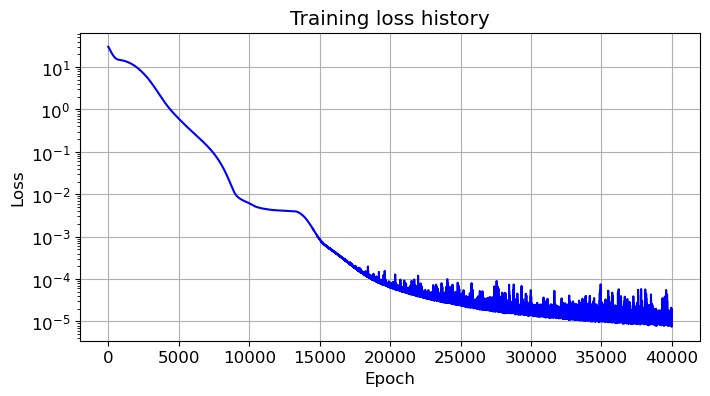

In [42]:
# loss history
plt.figure(figsize=(8, 4))
plt.plot(loss_history, '-b')
plt.yscale('log')          # optional if loss spans many orders of magnitude
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.grid(True)
plt.show()

#### save the model

In [ ]:
torch.save({
    'epoch': epoch,
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
}, 'checkpoint_gamma_5_3.pth')

#### load the model to continue training

In [ ]:
# checkpoint = torch.load('checkpoint_gamma_5_3.pth')
# model.load_state_dict(checkpoint['model_state'])
# optimizer.load_state_dict(checkpoint['optimizer_state'])
# start_epoch = checkpoint['epoch'] + 1


# start_epoch
# for epoch in range(start_epoch, start_epoch + 10000):
#     optimizer.zero_grad()
#     loss = compute_grhd_loss(model, X, X_0, output_ic, gamma, N_t, N_x)
#     loss.backward()
#     optimizer.step()
    
#     loss_val = loss.item()
#     loss_history.append(loss_val)
#     if loss_val < best_loss:
#         best_loss = loss_val
#         best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
#     if epoch % 1000 == 0:
#         print(f'Epoch {epoch:04d} | Loss = {loss_val:.6f} | Best = {best_loss:.6f}')

# print(f'\nFurther training complete. Best loss = {best_loss:.6f}')
# model.load_state_dict(best_model_state)


#### solution given in GA_PINNs_Repository at t=0.5. Load the analytical solution

In [223]:
import h5py
hf = h5py.File('Analytical_Solution_Test_1.h5', 'r')

In [224]:
hf.keys()

<KeysViewHDF5 ['dens_calculated', 'dens_initial', 'p_calculated', 'p_initial', 'ur_calculated', 'ur_initial', 'w_calculated', 'w_initial', 'x_space']>

In [230]:
x_f = torch.tensor(np.linspace(0,1,30), dtype=torch.float32).view(-1,1)
t_f = torch.tensor(0.5, dtype=torch.float32).repeat((30, 1))

In [226]:
x_analytical = torch.tensor(np.array(hf.get("x_space"))).view(-1, 1)
rho_analytical = torch.tensor(np.array(hf.get("dens_calculated"))).view(-1, 1)
ux_analytical = torch.tensor(np.array(hf.get("ur_calculated"))).view(-1, 1)
p_analytical = torch.tensor(np.array(hf.get("p_calculated"))).view(-1, 1)
hf.close()

In [227]:
t_analytical = torch.tensor(0.5, dtype=torch.float32).repeat((x_analytical.shape[0], 1))

In [228]:
analytical_space = torch.cat((t_analytical, x_analytical), dim=1)
analytical_variables = torch.cat((rho_analytical, ux_analytical, p_analytical), dim=1)

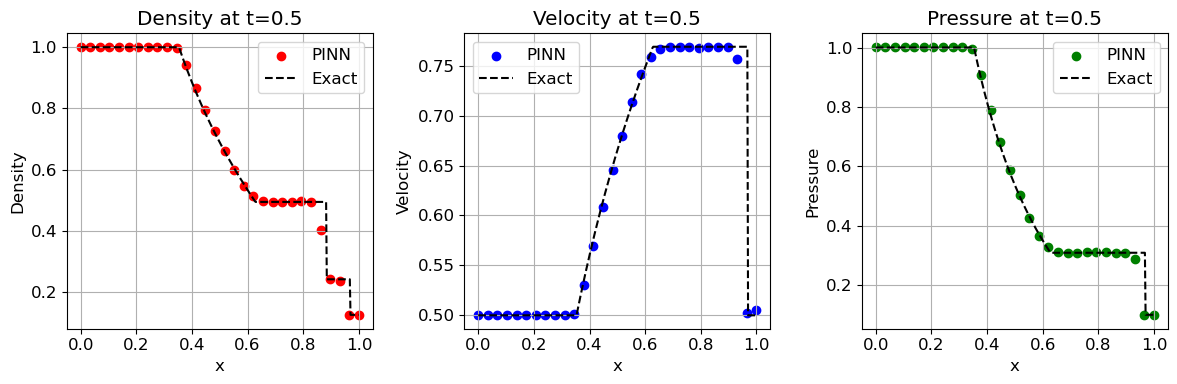

In [ ]:
pred_rho, pred_v, pred_p = model(x_f, t_f)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(x_f.numpy()[:, 0], pred_rho.detach().numpy()[:, 0], c='r', label='PINN')
plt.plot(analytical_space[:, 1].detach().cpu().numpy(), 
         analytical_variables[:, 0].detach().cpu().numpy(), 'k--', label='Exact')
plt.title('Density at t=0.5')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()  

plt.subplot(1, 3, 2)
plt.scatter(x_f.numpy()[:, 0], pred_v.detach().numpy()[:, 0], c='b', label='PINN')
plt.plot(analytical_space[:, 1].detach().cpu().numpy(), 
         analytical_variables[:, 1].detach().cpu().numpy(), 'k--', label='Exact')
plt.title('Velocity at t=0.5')
plt.xlabel('x')
plt.ylabel('Velocity')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(x_f.numpy()[:, 0], pred_p.detach().numpy()[:, 0], c='g', label='PINN')
plt.plot(analytical_space[:, 1].detach().cpu().numpy(), 
         analytical_variables[:, 2].detach().cpu().numpy(), 'k--', label='Exact')
plt.title('Pressure at t=0.5')
plt.xlabel('x')
plt.ylabel('Pressure')
plt.legend()
plt.tight_layout()
plt.savefig('grhd_sod_shocktube_comparison.png', dpi=300)
plt.show() 